In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
nasa = pd.read_csv("../data/PSCompPars_2025.10.22_08.26.30.csv", header=323)
phl = pd.read_csv("../data/hwc_2025.10.22.csv")

In [3]:
nasa["pl_name_norm"] = nasa["pl_name"].str.strip().str.lower()
phl["p_name_norm"] = phl["P_NAME"].str.strip().str.lower()

C:\Users\Dell\AppData\Local\Temp\ipykernel_7920\2999503160.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  nasa["pl_name_norm"] = nasa["pl_name"].str.strip().str.lower()


In [4]:
merged = pd.merge(
    nasa,
    phl,
    left_on="pl_name_norm",
    right_on="p_name_norm",
    how="inner"
)

In [5]:
merged.to_csv("../data/merged_data.csv", index=False)

In [6]:
df_orig = merged.copy()

In [7]:
df_train = pd.read_csv('../data/final_data.csv')

In [8]:
import joblib

model = joblib.load("../results/model.pkl")
scaler = joblib.load("../results/scaler.pkl")

In [9]:
uncertainty_columns = ['pl_orbeccenerr1', 'pl_orbeccenerr2', 'st_masserr1', 'st_masserr2', 'pl_orbpererr1', 'pl_orbpererr2']

In [10]:
df_train.columns

Index(['pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'P_RADIUS', 'P_MASS',
       'P_DENSITY', 'P_FLUX', 'P_TEMP_EQUIL', 'st_teff', 'st_mass', 'S_RADIUS',
       'S_LUMINOSITY', 'sy_dist', 'sy_pnum', 'P_ESI', 'P_HABITABLE'],
      dtype='str')

In [11]:
merge_keys = [
    'pl_orbper',
    'pl_orbsmax',
    'st_teff',
    'sy_dist'
]

In [12]:
cols_to_merge = merge_keys + uncertainty_columns

df_merged = df_train.merge(
    df_orig[cols_to_merge],
    on=merge_keys,
    how='left'
)

df_train.shape, df_merged.shape

((5281, 16), (5281, 22))

In [13]:
df_merged[uncertainty_columns].isna().mean()

pl_orbeccenerr1    0.696270
pl_orbeccenerr2    0.696270
st_masserr1        0.089188
st_masserr2        0.089377
pl_orbpererr1      0.134444
pl_orbpererr2      0.134444
dtype: float64

In [14]:
df_orig.duplicated(subset=merge_keys).sum()

np.int64(1)

In [15]:
df_merged.sample(5)[merge_keys + ['pl_orbeccen','pl_orbeccenerr1']]

,pl_orbper,pl_orbsmax,st_teff,sy_dist,pl_orbeccen,pl_orbeccenerr1
955,2443.000000,3.43000,5505.0,56.433,0.08,0.05
4344,3.222969,0.04078,5928.0,860.391,0.00,NaN
4183,4.583522,0.05350,6185.0,1156.830,0.00,NaN
4609,7.532806,0.07570,5690.0,446.442,0.00,NaN
3318,6.308205,0.06600,5190.0,738.792,0.00,NaN


In [16]:
features = df_train.drop(columns=['P_HABITABLE']).columns
features

Index(['pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'P_RADIUS', 'P_MASS',
       'P_DENSITY', 'P_FLUX', 'P_TEMP_EQUIL', 'st_teff', 'st_mass', 'S_RADIUS',
       'S_LUMINOSITY', 'sy_dist', 'sy_pnum', 'P_ESI'],
      dtype='str')

In [17]:
def perturb_row(row):
    new_row = row.copy()
    
    # --- Stellar Mass ---
    if pd.notna(row['st_masserr1']) and pd.notna(row['st_masserr2']):
        sigma = (abs(row['st_masserr1']) + abs(row['st_masserr2'])) / 2
        new_row['st_mass'] = np.random.normal(row['st_mass'], sigma)
    else:
        new_row['st_mass'] = row['st_mass'] * np.random.uniform(0.9, 1.1)
    
    # --- Orbital Period (optional but recommended) ---
    if pd.notna(row['pl_orbpererr1']) and pd.notna(row['pl_orbpererr2']):
        sigma = (abs(row['pl_orbpererr1']) + abs(row['pl_orbpererr2'])) / 2
        new_row['pl_orbper'] = np.random.normal(row['pl_orbper'], sigma)
    else:
        new_row['pl_orbper'] = row['pl_orbper'] * np.random.uniform(0.995, 1.005)
    
    # --- Eccentricity ---
    if pd.notna(row['pl_orbeccenerr1']) and pd.notna(row['pl_orbeccenerr2']):
        sigma = (abs(row['pl_orbeccenerr1']) + abs(row['pl_orbeccenerr2'])) / 2
        new_row['pl_orbeccen'] = np.clip(
            np.random.normal(row['pl_orbeccen'], sigma),
            0, 1
        )
    else:
        new_row['pl_orbeccen'] = np.clip(
            row['pl_orbeccen'] + np.random.uniform(-0.1, 0.1),
            0, 1
        )
    
    return new_row

In [18]:
def recompute_features(row):
    new_row = row.copy()
    
    # Semi-major axis
    if pd.notna(row['pl_orbper']) and pd.notna(row['st_mass']):
        new_row['pl_orbsmax'] = (row['pl_orbper']**2 * row['st_mass'])**(1/3)
    
    return new_row

In [19]:
def sample_predictions(row, model, scaler, features, N=50):
    preds = []
    
    for _ in range(N):
        new_row = perturb_row(row)
        new_row = recompute_features(new_row)
        
        X = pd.DataFrame([new_row[features]], columns=features)
        X_scaled = scaler.transform(X)
        
        pred = model.predict_proba(X_scaled)[0,1]
        preds.append(pred)
    
    return np.array(preds)

In [20]:
df_sample = df_merged.sample(100, random_state=42)

In [21]:
prediction_std = []
prediction_mean = []

for _, row in df_sample.iterrows():
    preds = sample_predictions(row, model, scaler, features, N=50)
    
    prediction_std.append(np.std(preds))
    prediction_mean.append(np.mean(preds))

In [22]:
prediction_std = np.array(prediction_std)
prediction_mean = np.array(prediction_mean)

In [23]:
print("Median std:", np.median(prediction_std))
print("Max std:", np.max(prediction_std))
print("Mean std:", np.mean(prediction_std))

Median std: 1.2482877e-07
Max std: 0.00014018266
Mean std: 2.8857096e-06


In [24]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

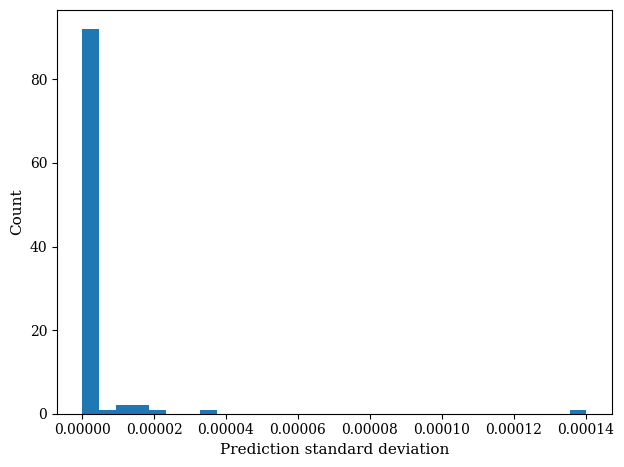

In [25]:
plt.figure()
plt.hist(prediction_std, bins=30)
plt.xlabel("Prediction standard deviation")
plt.ylabel("Count")
# plt.title("Prediction Sensitivity to Input Uncertainty")
plt.tight_layout()
plt.savefig("perturbation.pdf")
plt.show();

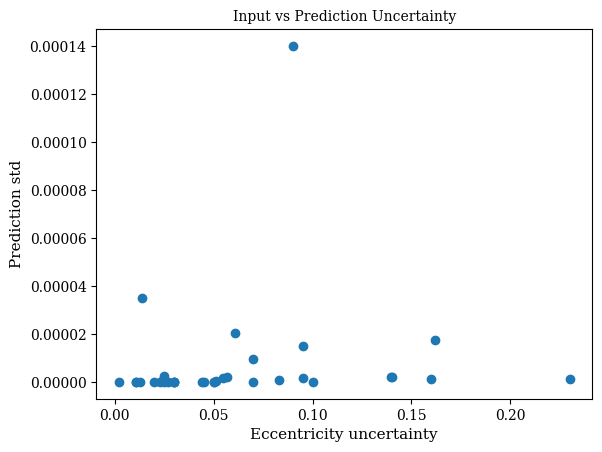

In [26]:
ecc_unc = df_sample['pl_orbeccenerr1'].abs()

plt.figure()
plt.scatter(ecc_unc, prediction_std)
plt.xlabel("Eccentricity uncertainty")
plt.ylabel("Prediction std")
plt.title("Input vs Prediction Uncertainty")
plt.show();